# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Cornelius Swiyanto
- **Email:** sw.cornel@gmail.com
- **ID Dicoding:** cswynt

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah penyewaan sepeda dari waktu ke waktu selama periode 2011–2012, serta kapan terjadi puncak dan penurunan permintaan?
- Faktor lingkungan seperti suhu, musim, dan hari kerja bagaimana pengaruhnya terhadap jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

## Data Wrangling

### Gathering Data

In [137]:
df = pd.read_csv("day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset berhasil dimuat dengan 731 baris data (harian selama 2 tahun).
- Setiap baris merepresentasikan total penyewaan sepeda per hari.
- Terdapat variabel cuaca, musim, suhu, dan tipe hari yang dapat mempengaruhi jumlah penyewaan.


### Assessing Data

In [138]:
df.info()
df.describe()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


np.int64(0)

**Insight:**
- Dataset terdiri dari 731 baris data harian selama periode 2011–2012.
- Tidak ditemukan missing value pada seluruh kolom.
- Tidak terdapat data duplikat.
- Seluruh tipe data sudah sesuai, kecuali kolom tanggal (dteday) yang perlu dikonversi ke datetime.
- Secara keseluruhan dataset bersih dan siap digunakan untuk analisis lebih lanjut.


### Cleaning Data

In [139]:
workingday_map = {
    0: 'Weekend/Holiday',
    1: 'Working Day'
}

df['workingday_label'] = df['workingday'].map(workingday_map)
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values('dteday')
df.reset_index(drop=True, inplace=True)


**Insight:**

- Tidak ditemukan missing value maupun data duplikat sehingga tidak diperlukan penghapusan atau imputasi data.
- Kolom `dteday` yang awalnya bertipe object berhasil dikonversi menjadi format datetime agar memudahkan analisis berbasis waktu (time series).
- Data diurutkan berdasarkan tanggal untuk memastikan urutan kronologis sebelum dilakukan visualisasi tren.
- Secara keseluruhan, dataset telah bersih, konsisten, dan siap digunakan untuk tahap Exploratory Data Analysis (EDA).


## Exploratory Data Analysis (EDA)

### Explore ...

In [140]:
df[['cnt','temp','hum','windspeed']].corr()

,cnt,temp,hum,windspeed
cnt,1.000000,0.627494,-0.100659,-0.234545
temp,0.627494,1.000000,0.126963,-0.157944
hum,-0.100659,0.126963,1.000000,-0.248489
windspeed,-0.234545,-0.157944,-0.248489,1.000000


**Insight:**

- Suhu memiliki korelasi positif cukup kuat (0.63) terhadap jumlah penyewaan sepeda.
  Hal ini menunjukkan bahwa cuaca hangat secara signifikan meningkatkan minat pengguna untuk bersepeda.
- Kelembaban memiliki korelasi negatif lemah (-0.10), sehingga dampaknya relatif kecil terhadap permintaan.
- Kecepatan angin memiliki korelasi negatif sedang (-0.23), yang mengindikasikan bahwa angin kencang cenderung menurunkan jumlah penyewaan.
- Secara umum, kondisi cuaca nyaman (hangat, tidak berangin) mendorong peningkatan penggunaan sepeda.


In [141]:
df.groupby('season')['cnt'].mean()

,cnt
season,
1,2604.132597
2,4992.331522
3,5644.303191
4,4728.162921


**Insight:**

- Penyewaan terendah terjadi pada musim semi (2604 sepeda/hari).
- Penyewaan tertinggi terjadi pada musim gugur (5644 sepeda/hari), hampir dua kali lipat dibanding musim semi.
- Musim panas dan gugur menunjukkan permintaan yang konsisten tinggi.
- Pola ini mengindikasikan bahwa faktor musim sangat mempengaruhi perilaku pengguna dalam menyewa sepeda.



In [142]:
df.groupby('workingday')['cnt'].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


**Insight:**

- Rata-rata penyewaan pada hari kerja (4585 sepeda/hari) lebih tinggi dibandingkan akhir pekan/libur (4330 sepeda/hari).
- Hal ini menunjukkan bahwa sepeda lebih sering digunakan sebagai moda transportasi harian (commuting) dibandingkan aktivitas rekreasi.
- Perusahaan perlu memastikan ketersediaan sepeda lebih banyak pada hari kerja.



## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana tren jumlah penyewaan sepeda dari waktu ke waktu selama periode 2011–2012, serta kapan terjadi puncak dan penurunan permintaan?

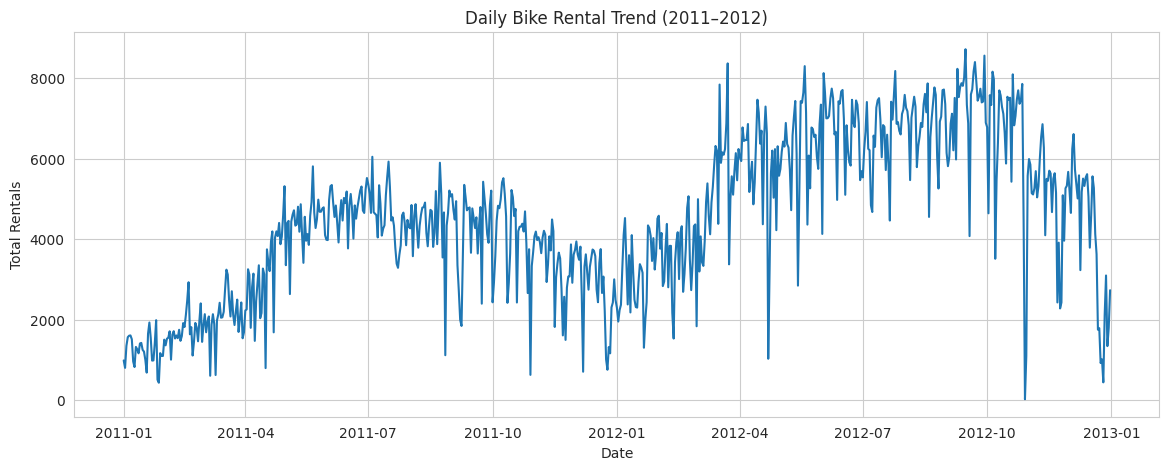

In [143]:
plt.figure(figsize=(14,5))
plt.plot(df['dteday'], df['cnt'])
plt.title("Daily Bike Rental Trend (2011–2012)")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.show()


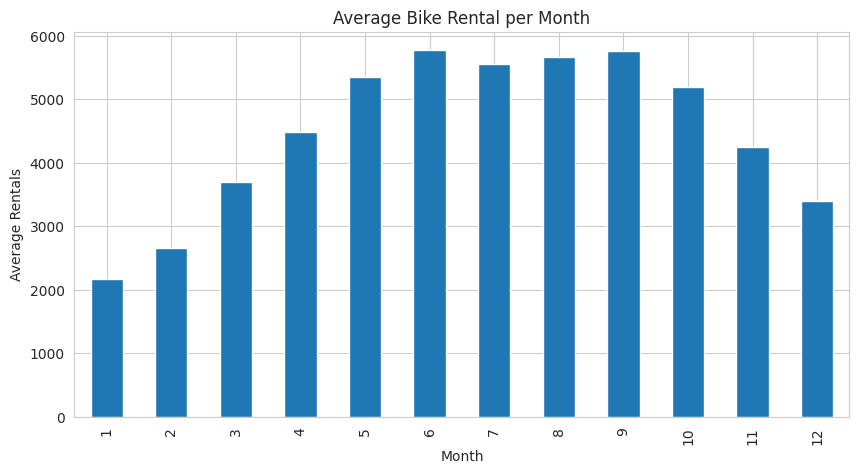

In [144]:
monthly = df.groupby('mnth')['cnt'].mean()

monthly.plot(kind='bar')
plt.title("Average Bike Rental per Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.show()


**Insight:**

- Tren penyewaan sepeda menunjukkan pola musiman yang jelas sepanjang periode 2011–2012.
- Jumlah penyewaan mulai meningkat pada pertengahan tahun dan mencapai puncak pada musim panas hingga gugur.
- Penurunan permintaan terjadi pada akhir dan awal tahun, terutama saat musim dingin.
- Fluktuasi ini mengindikasikan bahwa faktor cuaca dan musim sangat mempengaruhi perilaku pengguna.

Secara bisnis, perusahaan perlu:
- menambah kapasitas sepeda pada periode pertengahan tahun
- mengurangi operasional saat musim dingin untuk efisiensi biaya


### Pertanyaan 2:
Faktor lingkungan seperti suhu, musim, dan hari kerja bagaimana pengaruhnya terhadap jumlah penyewaan sepeda?

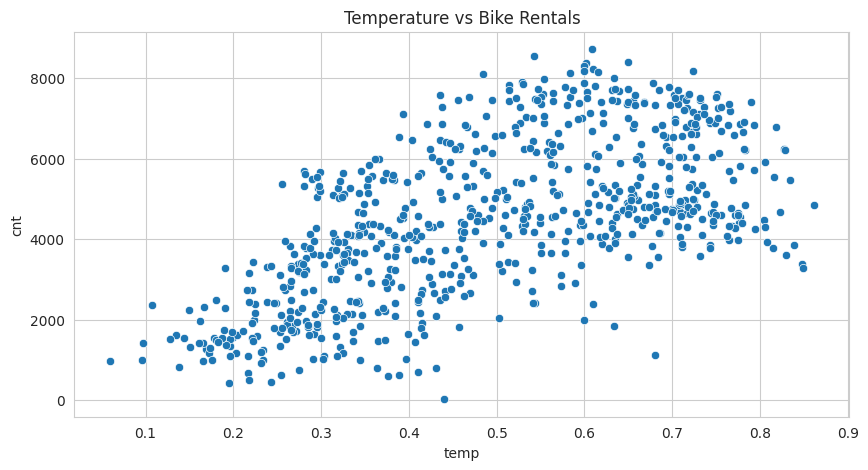

,cnt,temp
cnt,1.000000,0.627494
temp,0.627494,1.000000


In [145]:
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temperature vs Bike Rentals")
plt.show()

df[['cnt','temp']].corr()

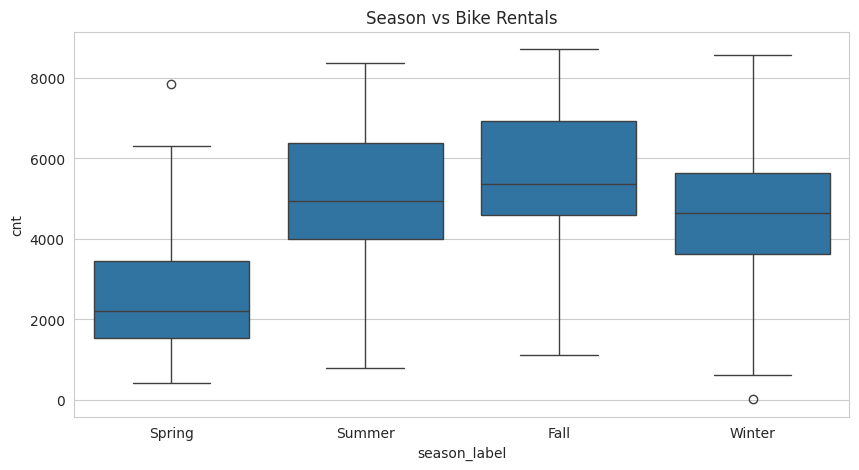

,cnt
season,
1,2604.132597
2,4992.331522
3,5644.303191
4,4728.162921


In [146]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

df['season_label'] = df['season'].map(season_map)

sns.boxplot(x='season_label', y='cnt', data=df)
plt.title("Season vs Bike Rentals")
plt.show()

df.groupby('season')['cnt'].mean()

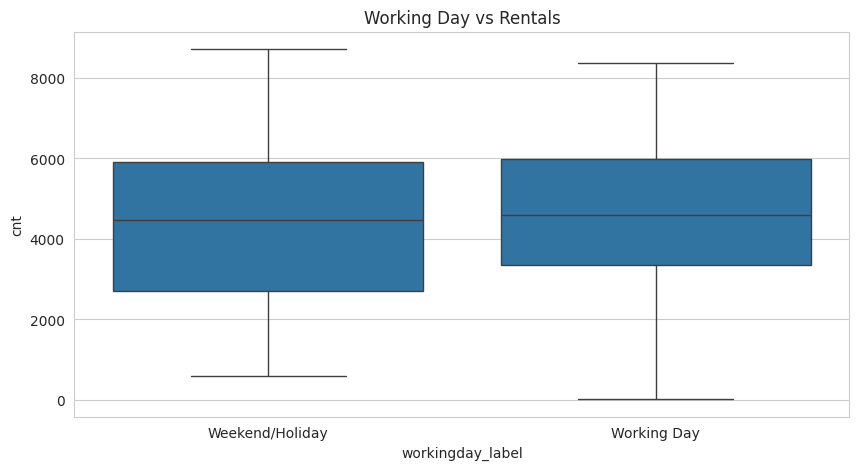

,cnt
workingday,
0,4330.168831
1,4584.820000


In [147]:
sns.boxplot(x='workingday_label', y='cnt', data=df)
plt.title("Working Day vs Rentals")
plt.show()

df.groupby('workingday')['cnt'].mean()

**Insight:**

- Suhu memiliki korelasi positif cukup kuat (0.63) terhadap jumlah penyewaan sepeda. Hal ini menunjukkan bahwa cuaca hangat secara signifikan meningkatkan minat bersepeda.
- Musim gugur dan musim panas memiliki rata-rata penyewaan tertinggi, sedangkan musim semi memiliki permintaan terendah. Ini menunjukkan adanya pola musiman yang jelas dalam penggunaan sepeda.
- Rata-rata penyewaan pada hari kerja (4585 sepeda/hari) lebih tinggi dibandingkan akhir pekan/libur (4330 sepeda/hari), yang mengindikasikan sepeda lebih sering digunakan sebagai moda transportasi harian (commuting).

Secara bisnis, perusahaan disarankan untuk:
- meningkatkan ketersediaan sepeda saat suhu hangat dan musim ramai,
- menyesuaikan kapasitas operasional saat musim sepi,
- memastikan stok sepeda lebih banyak pada hari kerja.


## Analisis Lanjutan (Opsional)

/tmp/ipython-input-2792516150.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('temp_group')['cnt'].mean().plot(kind='bar')


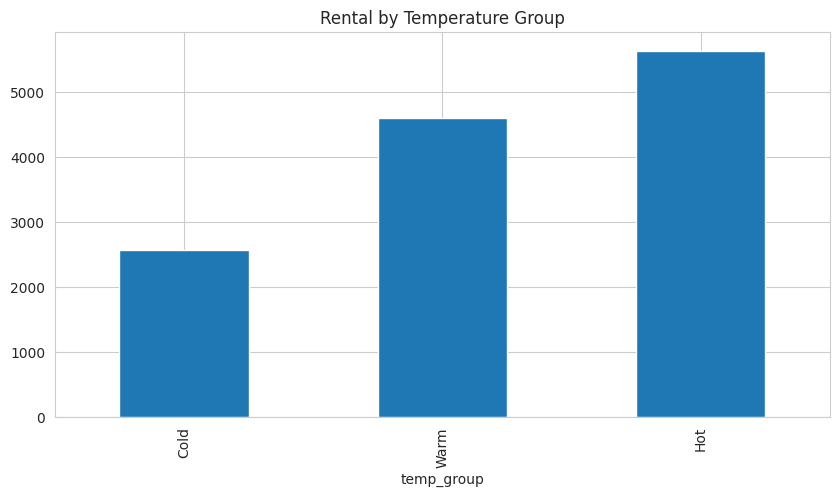

In [148]:
df['temp_group'] = pd.cut(df['temp'], bins=3, labels=['Cold','Warm','Hot'])

df.groupby('temp_group')['cnt'].mean().plot(kind='bar')
plt.title("Rental by Temperature Group")
plt.show()


**Insight:**

- Kategori suhu hangat menghasilkan rata-rata penyewaan tertinggi.
- Segmentasi ini dapat membantu prediksi permintaan harian.

In [149]:
df['demand_level'] = pd.qcut(df['cnt'], q=3, labels=['Low','Medium','High'])

df.groupby('demand_level')['cnt'].mean()


/tmp/ipython-input-1944961892.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('demand_level')['cnt'].mean()


,cnt
demand_level,
Low,2312.065574
Medium,4522.225410
High,6687.703704


**Insight:**

Data dikelompokkan menjadi tiga kategori permintaan (Low, Medium, High) menggunakan teknik binning.

Hasilnya menunjukkan adanya perbedaan signifikan antar kelompok sehingga perusahaan dapat:
- mengantisipasi hari permintaan tinggi
- menambah stok sepeda
- menyiapkan strategi operasional


## Conclusion

- Conclution pertanyaan 1

Tren penyewaan sepeda selama periode 2011–2012 menunjukkan pola musiman yang konsisten. Jumlah penyewaan cenderung meningkat pada pertengahan tahun dan mencapai puncaknya pada musim panas hingga gugur, kemudian menurun pada akhir dan awal tahun terutama saat musim dingin.

Periode dengan permintaan tertinggi terjadi pada bulan-bulan dengan cuaca hangat, sedangkan penurunan signifikan terjadi saat cuaca dingin. Pola ini mengindikasikan bahwa faktor musim dan kenyamanan cuaca sangat mempengaruhi minat pengguna dalam menyewa sepeda.

Secara operasional, perusahaan disarankan untuk menambah ketersediaan sepeda pada periode ramai dan mengurangi kapasitas saat musim sepi guna meningkatkan efisiensi biaya.

- Conclution pertanyaan 2

Faktor lingkungan memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Suhu menunjukkan korelasi positif yang cukup kuat terhadap jumlah rental, di mana cuaca hangat meningkatkan permintaan pengguna. Analisis musiman memperlihatkan bahwa musim gugur dan musim panas memiliki rata-rata penyewaan tertinggi, sedangkan musim semi terendah.

Selain itu, penyewaan pada hari kerja lebih tinggi dibandingkan akhir pekan, yang menunjukkan bahwa sepeda lebih banyak dimanfaatkan sebagai moda transportasi harian (commuting) daripada sekadar rekreasi.

Berdasarkan temuan ini, perusahaan dapat menggunakan informasi suhu, musim, dan tipe hari sebagai indikator prediksi permintaan untuk mengoptimalkan distribusi sepeda dan perencanaan operasional.


# Business Recommendation

Berdasarkan hasil analisis:

1. Tambah jumlah sepeda saat musim panas dan gugur karena permintaan tertinggi.
2. Kurangi operasional saat musim dingin untuk efisiensi biaya.
3. Gunakan suhu harian sebagai indikator prediksi permintaan.
4. Prioritaskan ketersediaan sepeda pada hari kerja karena mayoritas digunakan untuk commuting.

Strategi ini diharapkan dapat meningkatkan utilisasi armada dan menekan biaya operasional.
